Model 1 trained
Model 2 trained
Model 3 trained
Model 4 trained
Model 5 trained


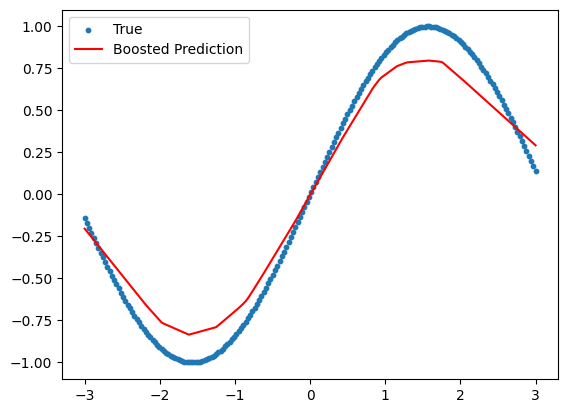

In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------------
# Fake dataset
# y = sin(x)
# -----------------------------
x = torch.linspace(-3, 3, 200).view(-1, 1)
y = torch.sin(x)

# -----------------------------
# Weak learnerm
# tiny neural network
# -----------------------------
class WeakLearner(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Gradient Boosting
# -----------------------------
n_estimators = 5
learning_rate = 0.3

models = []

# Initial prediction = zeros
pred = torch.zeros_like(y)

for i in range(n_estimators):

    # Residuals (errors)
    residual = y - pred

    # Train weak learner on residuals
    model = WeakLearner()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    for epoch in range(300):

        output = model(x)

        loss = loss_fn(output, residual)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Add model prediction to ensemble
    with torch.no_grad():
        pred += learning_rate * model(x)

    models.append(model)

    print(f"Model {i+1} trained")

# -----------------------------
# Plot results
# -----------------------------
plt.scatter(x.numpy(), y.numpy(), s=10, label="True")

plt.plot(
    x.numpy(),
    pred.detach().numpy(),
    color='red',
    label='Boosted Prediction'
)

plt.legend()
plt.show()